In [5]:
import sys
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns


In [6]:
from pandas import read_csv

df = read_csv("train.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [7]:
# Displays the first five records of the dataset
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
# Displays the last five records of the dataset
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [9]:
df.shape

(891, 12)

In [10]:
rows, columns = df.shape

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 891
Number of columns: 12


In [11]:
df["PassengerId"]

,PassengerId
0,1
1,2
2,3
3,4
4,5
...,...
886,887
887,888
888,889
889,890


In [12]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [13]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [14]:
df.dtypes.value_counts()

,count
int64,5
object,5
float64,2


In [15]:
missing_data = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


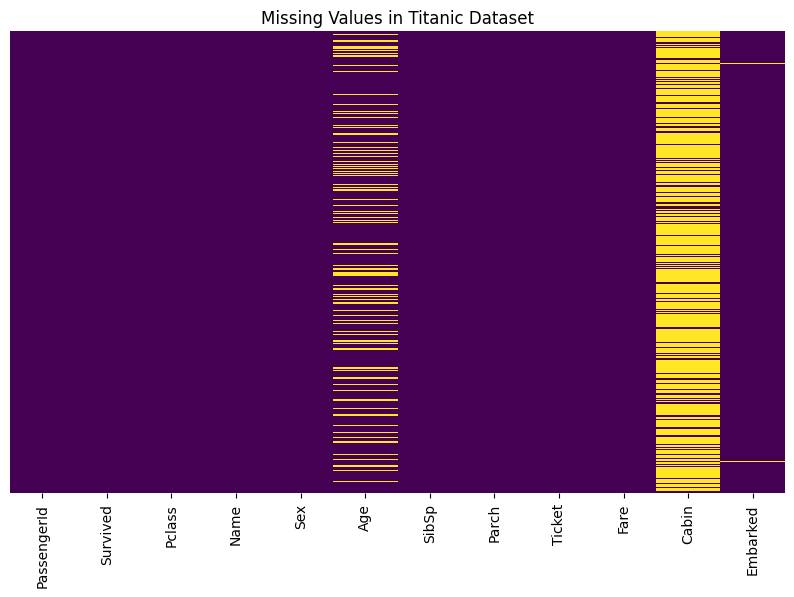

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values in Titanic Dataset")
plt.show()

In [17]:
duplicate_rows = df[df.duplicated()]

print(f"Total duplicate rows detected: {len(duplicate_rows)}")
print(duplicate_rows)

print("-" * 40)

Total duplicate rows detected: 0
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []
----------------------------------------


In [18]:
df[df["Age"].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
19,20,1,3,"Masselmani, Mrs. Fatima",female,NaN,0,0,2649,7.2250,NaN,C
26,27,0,3,"Emir, Mr. Farred Chehab",male,NaN,0,0,2631,7.2250,NaN,C
28,29,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,NaN,0,0,330959,7.8792,NaN,Q
...,...,...,...,...,...,...,...,...,...,...,...,...
859,860,0,3,"Razi, Mr. Raihed",male,NaN,0,0,2629,7.2292,NaN,C
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S
868,869,0,3,"van Melkebeke, Mr. Philemon",male,NaN,0,0,345777,9.5000,NaN,S
878,879,0,3,"Laleff, Mr. Kristo",male,NaN,0,0,349217,7.8958,NaN,S


In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

print("Duplicates removed successfully!")

Duplicates removed successfully!


In [21]:
df.shape

(891, 12)

In [22]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [23]:
print("Survival Class Distribution")

df["Survived"].value_counts()

Survival Class Distribution


,count
Survived,
0,549
1,342


In [24]:
(df["Survived"].value_counts(normalize=True) * 100).round(2)

,proportion
Survived,
0,61.62
1,38.38


In [25]:
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = df.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numerical_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

Categorical Features:
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


In [26]:
numerical_cols = df.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Numerical Columns:")
print(numerical_cols)

Numerical Columns:
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [27]:
corr_matrix = df[numerical_cols].corr()

print("\n--- Correlation Matrix ---")
print(corr_matrix)


--- Correlation Matrix ---
             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.036847 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.077221 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.369226  0.083081  0.018443   
Age             0.036847 -0.077221 -0.369226  1.000000 -0.308247 -0.189119   
SibSp          -0.057527 -0.035322  0.083081 -0.308247  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.189119  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096067  0.159651  0.216225   

                 Fare  
PassengerId  0.012658  
Survived     0.257307  
Pclass      -0.549500  
Age          0.096067  
SibSp        0.159651  
Parch        0.216225  
Fare         1.000000  


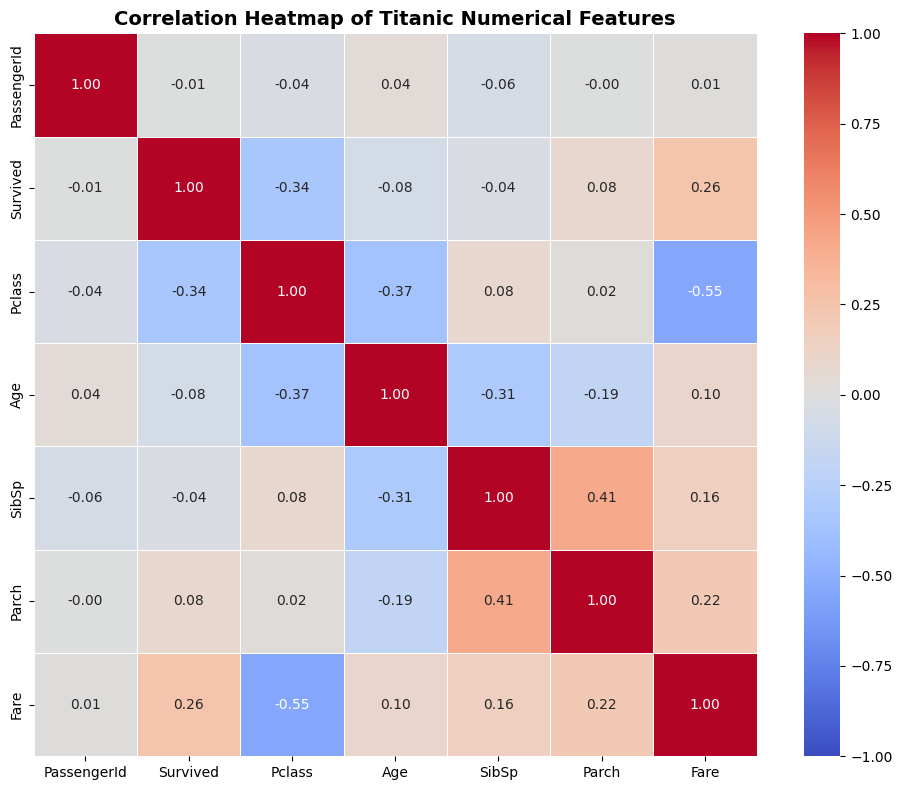

In [28]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Titanic Numerical Features",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

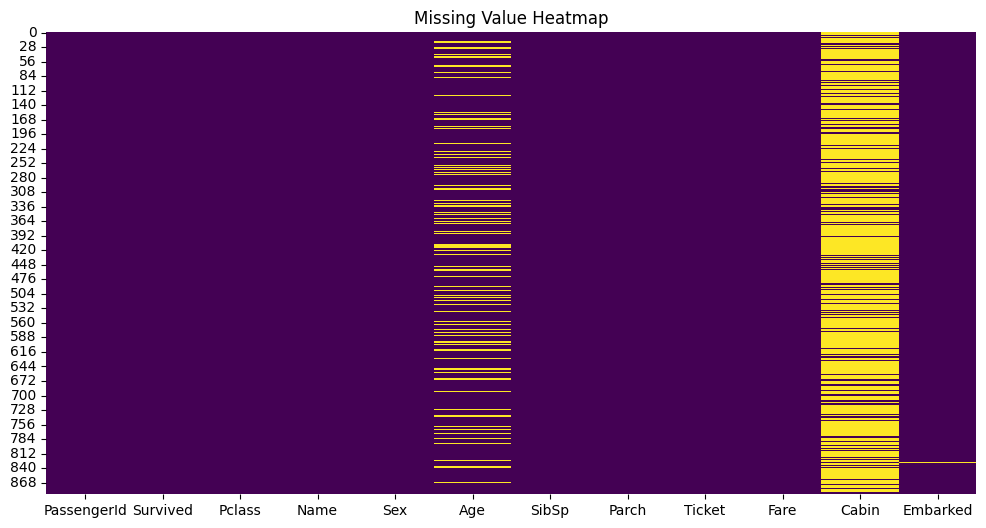

In [29]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

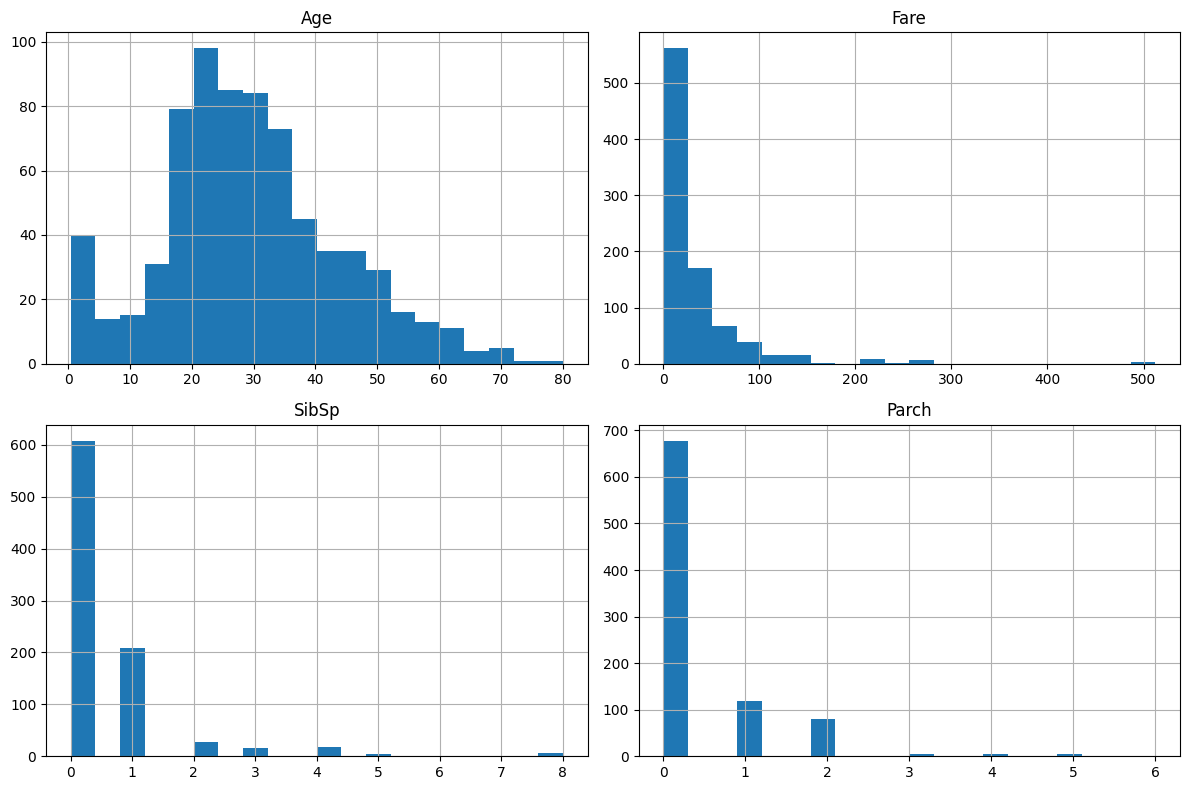

In [30]:
features = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

df[features].hist(
    bins=20,
    figsize=(12, 8)
)

plt.tight_layout()
plt.show()

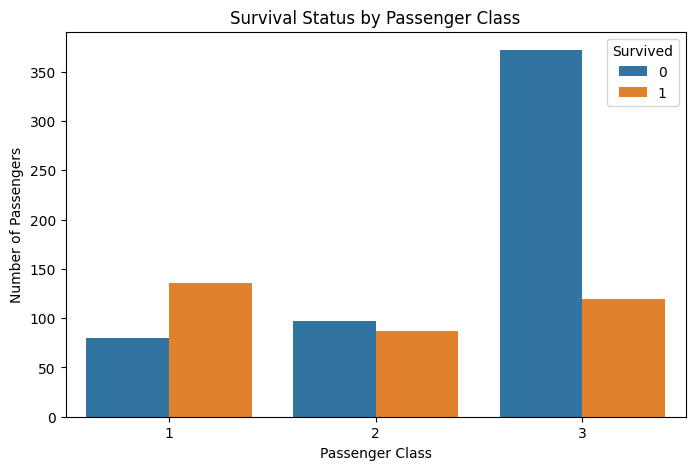

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Pclass",
    hue="Survived"
)

plt.title("Survival Status by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

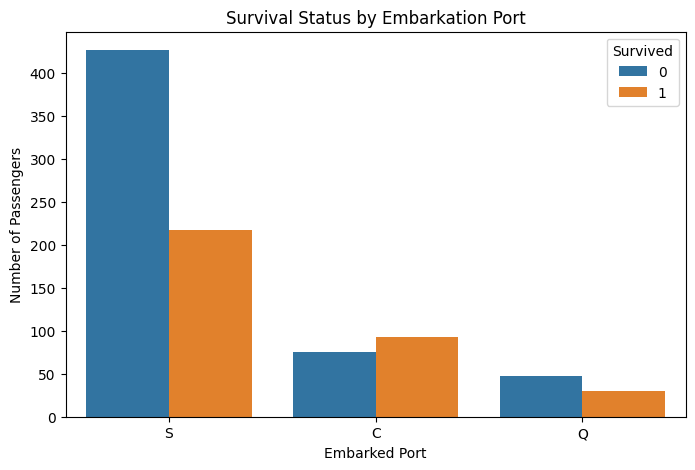

In [32]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Embarked",
    hue="Survived"
)

plt.title("Survival Status by Embarkation Port")
plt.xlabel("Embarked Port")
plt.ylabel("Number of Passengers")

plt.show()

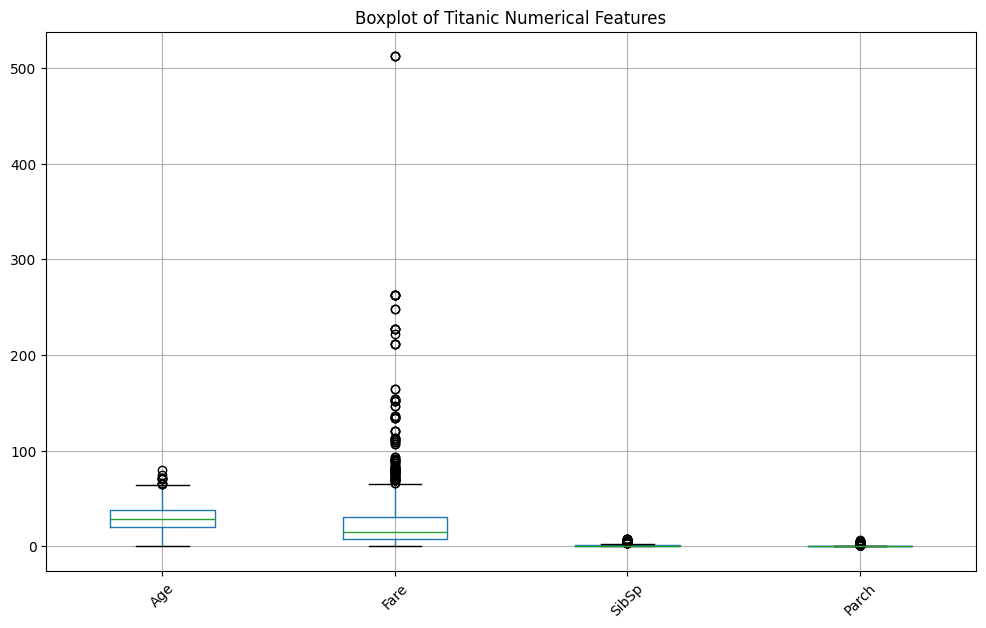

In [33]:
numerical_columns = [
    "Age",
    "Fare",
    "SibSp",
    "Parch"
]

plt.figure(figsize=(12, 7))

df[numerical_columns].boxplot()

plt.xticks(rotation=45)

plt.title("Boxplot of Titanic Numerical Features")

plt.show()

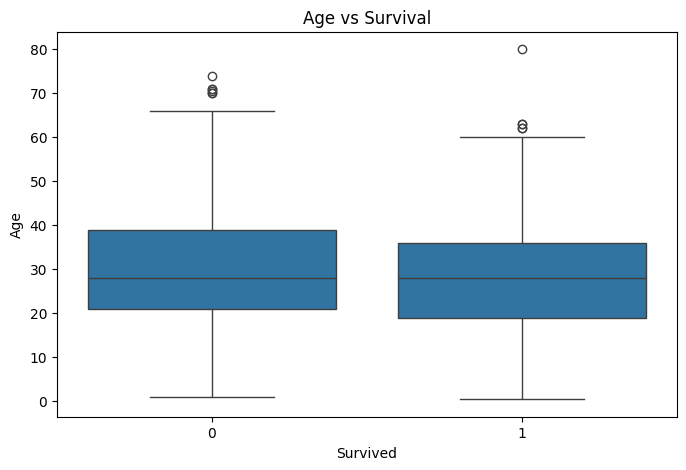

In [34]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Survived",
    y="Age",
    data=df
)

plt.title("Age vs Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.show()

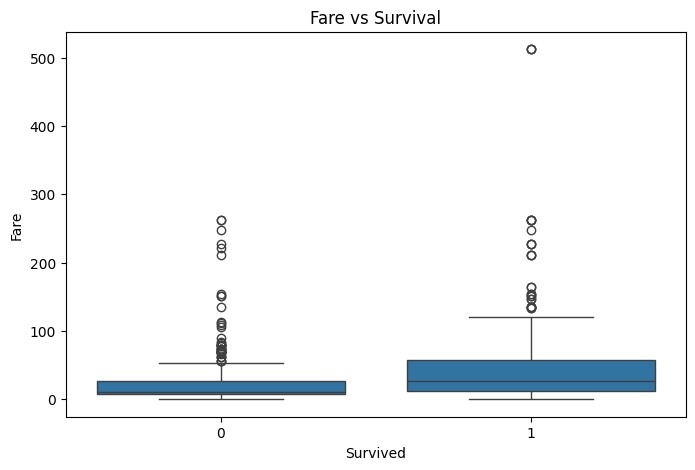

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="Survived",
    y="Fare",
    data=df
)

plt.title("Fare vs Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")

plt.show()

In [36]:
survival_gender = pd.crosstab(
    df["Sex"],
    df["Survived"],
    normalize="index"
) * 100

print(survival_gender.round(2))

Survived      0      1
Sex                   
female    25.80  74.20
male      81.11  18.89


In [37]:
survival_class = pd.crosstab(
    df["Pclass"],
    df["Survived"],
    normalize="index"
) * 100

print(survival_class.round(2))

Survived      0      1
Pclass                
1         37.04  62.96
2         52.72  47.28
3         75.76  24.24


In [38]:
print("=" * 50)
print("FINAL TITANIC DATASET SUMMARY")
print("=" * 50)

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
print(df.describe())

print("\nSurvival Distribution:")
print(df["Survived"].value_counts())

print("\nSurvival Percentage:")
print((df["Survived"].value_counts(normalize=True) * 100).round(2))

FINAL TITANIC DATASET SUMMARY

Dataset Shape:
(891, 12)

Columns:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Duplicate Rows:
0

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std  